Данные с каггла https://www.kaggle.com/competitions/spaceship-titanic/data?select=train.csv

# Разведочный анализ, заполнение пропусков, преобразование категориальных признаков

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("train.csv")
data.head(10)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
5,0005_01,Earth,False,F/0/P,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,True
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,True
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,NaN,Candra Jacostaffey,True
8,0007_01,Earth,False,F/3/S,TRAPPIST-1e,35.0,False,0.0,785.0,17.0,216.0,0.0,Andona Beston,True
9,0008_01,Europa,True,B/1/P,55 Cancri e,14.0,False,0.0,0.0,0.0,0.0,0.0,Erraiam Flatic,True


In [3]:
data.dtypes

PassengerId         str
HomePlanet          str
CryoSleep        object
Cabin               str
Destination         str
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name                str
Transported        bool
dtype: object

In [4]:
data.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [5]:
total_count = data.shape[0]
num_cols = []
for col in data.columns:
    # Количество пустых значений 
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='float64' or dt=='int64'):
        num_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка Age. Тип данных float64. Количество пустых значений 179, 2.06%.
Колонка RoomService. Тип данных float64. Количество пустых значений 181, 2.08%.
Колонка FoodCourt. Тип данных float64. Количество пустых значений 183, 2.11%.
Колонка ShoppingMall. Тип данных float64. Количество пустых значений 208, 2.39%.
Колонка Spa. Тип данных float64. Количество пустых значений 183, 2.11%.
Колонка VRDeck. Тип данных float64. Количество пустых значений 188, 2.16%.


In [6]:
cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
data[cols] = data[cols].fillna(data[cols].mean())

In [7]:
cat_cols = []
for col in data.columns:
    # Количество пустых значений 
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='object' or dt=='str'):
        cat_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка HomePlanet. Тип данных str. Количество пустых значений 201, 2.31%.
Колонка CryoSleep. Тип данных object. Количество пустых значений 217, 2.5%.
Колонка Cabin. Тип данных str. Количество пустых значений 199, 2.29%.
Колонка Destination. Тип данных str. Количество пустых значений 182, 2.09%.
Колонка VIP. Тип данных object. Количество пустых значений 203, 2.34%.
Колонка Name. Тип данных str. Количество пустых значений 200, 2.3%.


In [8]:
categorical_cols = ['HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP', 'Name']
for col in categorical_cols:
    if col in data.columns:
        mode_val = data[col].mode()[0]  
        data[col] = data[col].fillna(mode_val)
        print(f"Столбец '{col}' заполнен значением: {mode_val}")

Столбец 'HomePlanet' заполнен значением: Earth
Столбец 'CryoSleep' заполнен значением: False
Столбец 'Cabin' заполнен значением: G/734/S
Столбец 'Destination' заполнен значением: TRAPPIST-1e
Столбец 'VIP' заполнен значением: False
Столбец 'Name' заполнен значением: Alraium Disivering


In [9]:
data.isnull().sum()

PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
Transported     0
dtype: int64

In [10]:
data[['Deck', 'CabinNumber', 'Side']] = data['Cabin'].str.split('/', expand=True)
data['CabinNumber'] = pd.to_numeric(data['CabinNumber'])
data[['Cabin', 'Deck', 'CabinNumber', 'Side']].head()

,Cabin,Deck,CabinNumber,Side
0,B/0/P,B,0,P
1,F/0/S,F,0,S
2,A/0/S,A,0,S
3,A/0/S,A,0,S
4,F/1/S,F,1,S


In [11]:
data['Destination'].unique()

<StringArray>
['TRAPPIST-1e', 'PSO J318.5-22', '55 Cancri e']
Length: 3, dtype: str

In [16]:
from sklearn.preprocessing import OrdinalEncoder
# One - Hot Encoding категориальных признаков
data_encoded = pd.get_dummies(
    data,
    columns=['HomePlanet', 'Destination'],
    prefix=['HomePlanet', 'Destination']
)
# Удаление ненужных столбцов
data_encoded = data_encoded.drop(columns=['Cabin', 'PassengerId', 'Name'])
# OrdinalEncoder оставшихся признаков
oe = OrdinalEncoder()
data_encoded[['Deck','Side']] = oe.fit_transform(data_encoded[['Deck','Side' ]])
col = data_encoded.pop('Transported')
data_encoded['Transported'] = col
data_encoded.head()

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Deck,CabinNumber,Side,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,Transported
0,False,39.0,False,0.0,0.0,0.0,0.0,0.0,1.0,0,0.0,False,True,False,False,False,True,False
1,False,24.0,False,109.0,9.0,25.0,549.0,44.0,5.0,0,1.0,True,False,False,False,False,True,True
2,False,58.0,True,43.0,3576.0,0.0,6715.0,49.0,0.0,0,1.0,False,True,False,False,False,True,False
3,False,33.0,False,0.0,1283.0,371.0,3329.0,193.0,0.0,0,1.0,False,True,False,False,False,True,False
4,False,16.0,False,303.0,70.0,151.0,565.0,2.0,5.0,1,1.0,True,False,False,False,False,True,True


<Axes: >

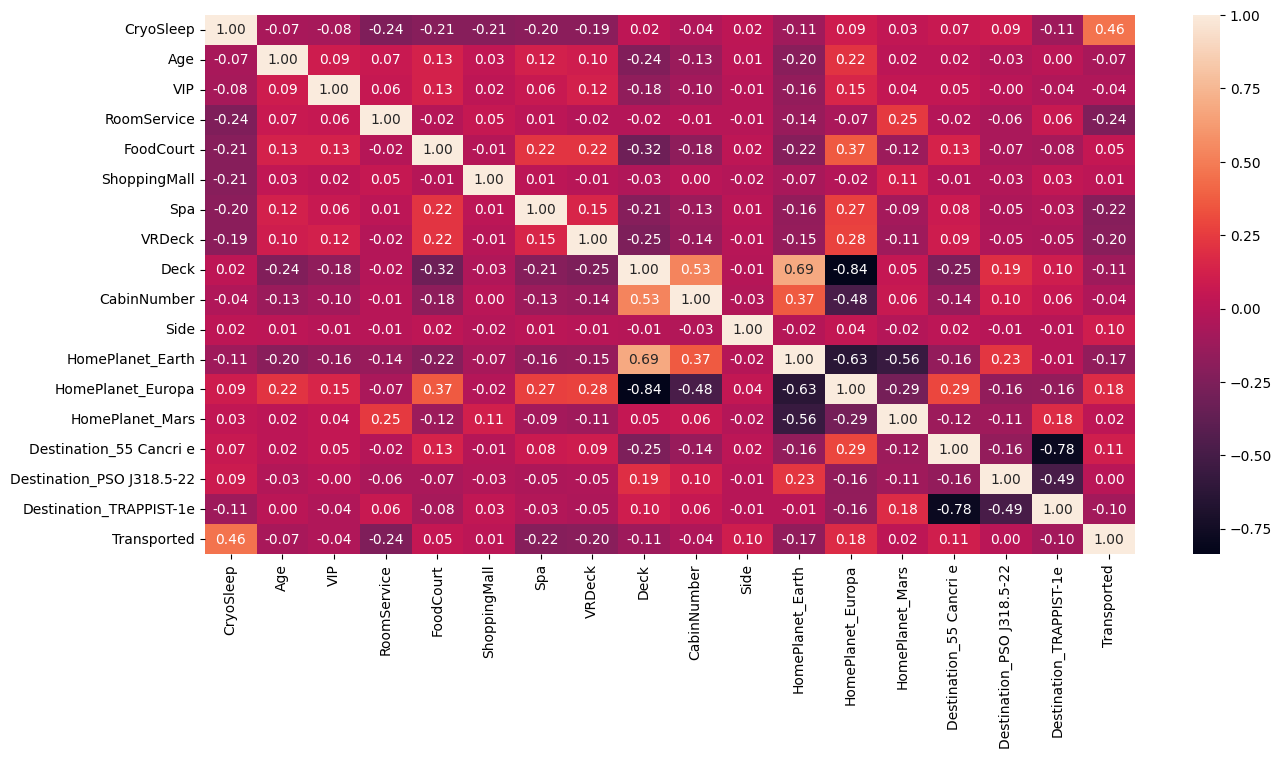

In [17]:
fig, ax = plt.subplots(figsize=(15,7))
sns.heatmap(data_encoded.corr(method='pearson'), ax=ax, annot=True, fmt='.2f')

In [18]:
X = data_encoded.drop(columns=['Transported'])
y = data_encoded['Transported']

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, roc_auc_score
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Логистическая кривая

In [25]:
log_reg_model = LogisticRegression(max_iter=5000)
log_reg_model.fit(X_train_scaled, y_train)
y_pred_log_reg = log_reg_model.predict(X_test_scaled)
y_proba_log_reg = log_reg_model.predict_proba(X_test_scaled)[:, 1]
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_log_reg):.4f}")

Accuracy: 0.7798
ROC-AUC: 0.8666


# Метод опорных векторов

In [26]:
SVC_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)
SVC_model.fit(X_train_scaled, y_train)
y_pred_SVC = SVC_model.predict(X_test_scaled)
y_proba_SVC = SVC_model.predict_proba(X_test_scaled)[:, 1]
print(f"Accuracy: {accuracy_score(y_test, y_pred_SVC):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_SVC):.4f}")

Accuracy: 0.7855
ROC-AUC: 0.8711


# Дерево решений

In [27]:
tree_model = DecisionTreeClassifier(
    max_depth=7,
    random_state=42
)
tree_model.fit(X_train_scaled, y_train)
y_pred_tree = tree_model.predict(X_test_scaled)
y_proba_tree = tree_model.predict_proba(X_test_scaled)[:, 1]
print(f"Accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_tree):.4f}")

Accuracy: 0.7734
ROC-AUC: 0.8570


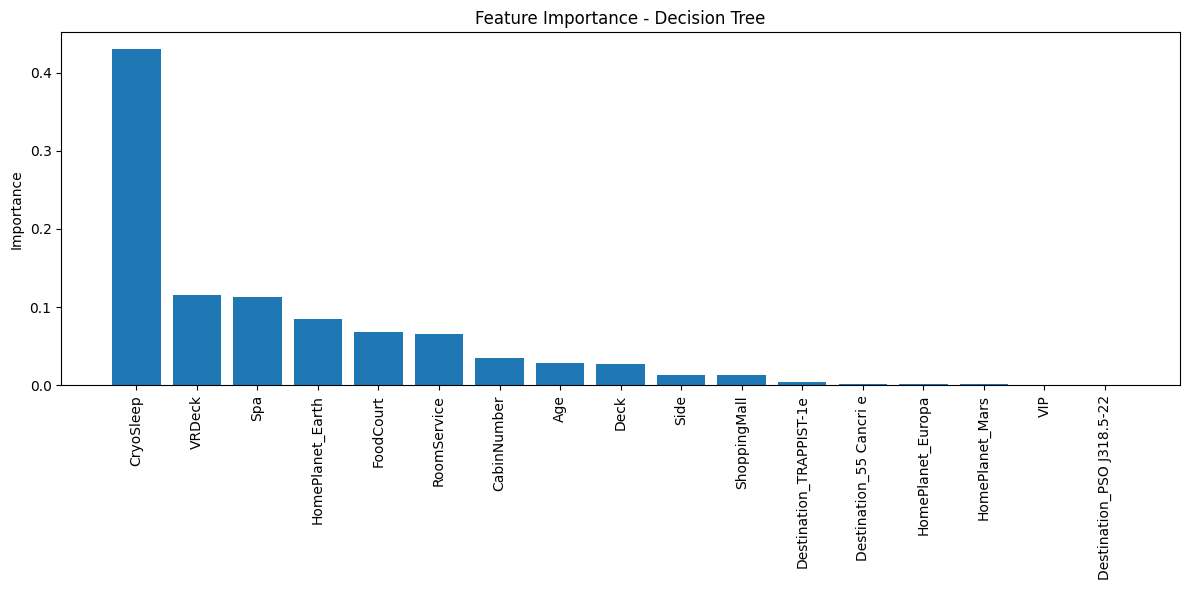

In [28]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tree_model.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
# График важности признаков
plt.figure(figsize=(12, 6))
plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)
plt.xticks(rotation=90)
plt.title("Feature Importance - Decision Tree")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

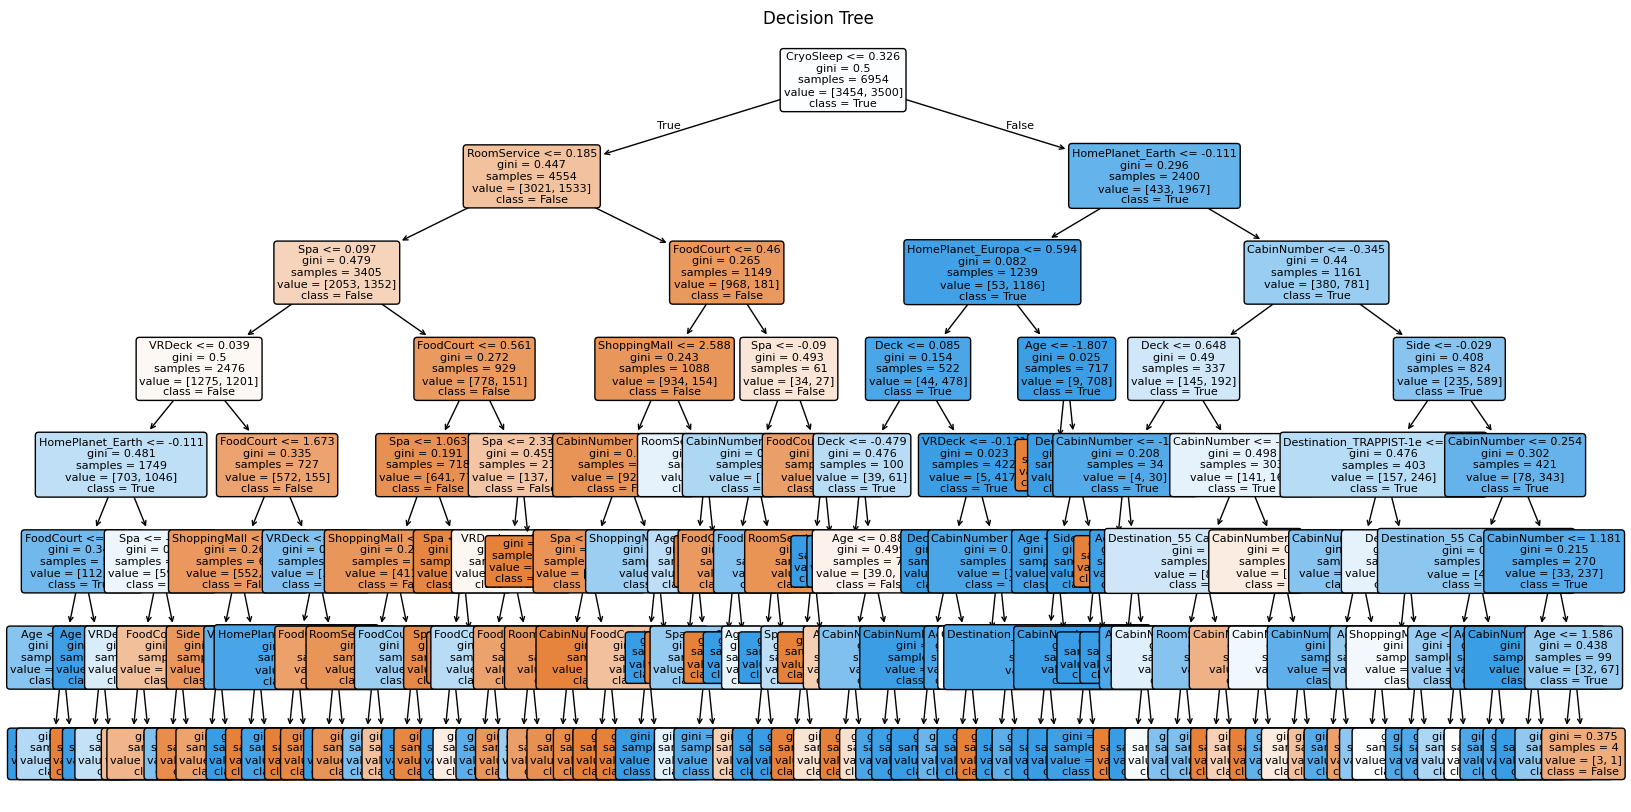

In [29]:
plt.figure(figsize=(20, 10))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=['False', 'True'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree")
plt.show()

In [30]:
tree_rules = export_text(
    tree_model,
    feature_names=list(X.columns)
)

print(tree_rules)

|--- CryoSleep <= 0.33
|   |--- RoomService <= 0.18
|   |   |--- Spa <= 0.10
|   |   |   |--- VRDeck <= 0.04
|   |   |   |   |--- HomePlanet_Earth <= -0.11
|   |   |   |   |   |--- FoodCourt <= 0.77
|   |   |   |   |   |   |--- Age <= -1.14
|   |   |   |   |   |   |   |--- class: True
|   |   |   |   |   |   |--- Age >  -1.14
|   |   |   |   |   |   |   |--- class: True
|   |   |   |   |   |--- FoodCourt >  0.77
|   |   |   |   |   |   |--- Age <= -0.97
|   |   |   |   |   |   |   |--- class: False
|   |   |   |   |   |   |--- Age >  -0.97
|   |   |   |   |   |   |   |--- class: True
|   |   |   |   |--- HomePlanet_Earth >  -0.11
|   |   |   |   |   |--- Spa <= -0.17
|   |   |   |   |   |   |--- VRDeck <= -0.15
|   |   |   |   |   |   |   |--- class: True
|   |   |   |   |   |   |--- VRDeck >  -0.15
|   |   |   |   |   |   |   |--- class: False
|   |   |   |   |   |--- Spa >  -0.17
|   |   |   |   |   |   |--- FoodCourt <= 0.19
|   |   |   |   |   |   |   |--- class: False
|   |   |   

# Сравнение и выводы

                 Model  Accuracy   ROC-AUC
0  Logistic Regression  0.779758  0.866639
1                  SVC  0.785509  0.871050
2        Decision Tree  0.773433  0.857040


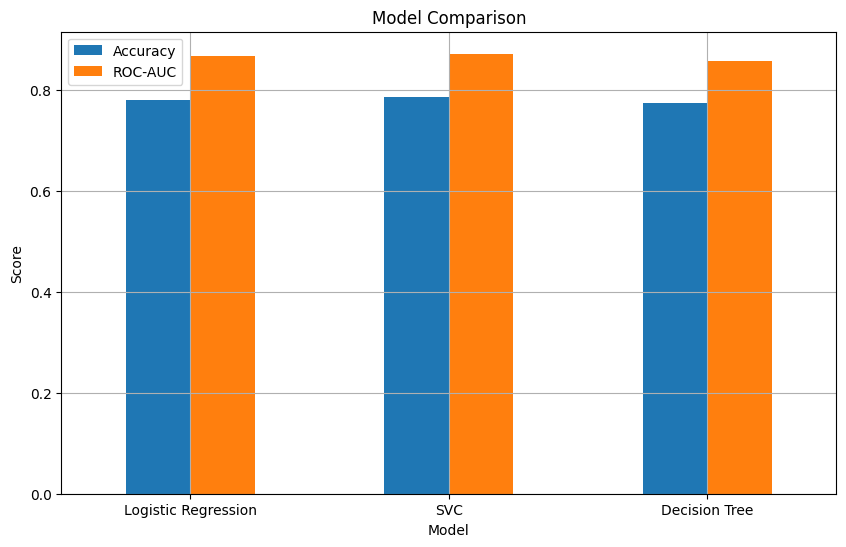

In [31]:
results = []

results.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred_log_reg),
    'ROC-AUC': roc_auc_score(y_test, y_proba_log_reg)
})

results.append({
    'Model': 'SVC',
    'Accuracy': accuracy_score(y_test, y_pred_SVC),
    'ROC-AUC': roc_auc_score(y_test, y_proba_SVC)
})

results.append({
    'Model': 'Decision Tree',
    'Accuracy': accuracy_score(y_test, y_pred_tree),
    'ROC-AUC': roc_auc_score(y_test, y_proba_tree)
})

# Создаем DataFrame
results_df = pd.DataFrame(results)

print(results_df)

# График
results_df.set_index('Model')[['Accuracy', 'ROC-AUC']].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title("Model Comparison")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.grid(True)

plt.show()

Получаем, что метод наилучших векторов по сравниваемым метрикам (точность и Roc-AUC) лучше